# Missing Data Analysis

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import seaborn as sns
import sys

## Loading the datasets

In [12]:
BASE_DIR = Path.cwd().parent
sys.path.append(str(BASE_DIR))

PROCESSED_DIR = BASE_DIR / "data"/ "processed"
COMPANIES_DIR = BASE_DIR / "data" / "raw" / "companies"

feature_matrix_path = os.path.join(PROCESSED_DIR, "feature_matrix_first.parquet")
prices_matrix_path = os.path.join(COMPANIES_DIR, "prices.parquet")

feature_matrix_df = pd.read_parquet(feature_matrix_path)
prices_df = pd.read_parquet(prices_matrix_path)

In [5]:
feature_matrix_df.head()

,Date,Ticker,market_beta_63,industry_beta_63,market_resid_vol_126,industry_resid_vol_126,mean_volatility_10,mean_volatility_21,mean_volatility_63,amihud_21,momentum_252_21,momentum_liquidity_21,reversal_5,rsr_21,future_return_5d
0,2022-06-14,360.AX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.035714
1,2022-06-14,4DX.AX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.177778
2,2022-06-14,A2M.AX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.023866
3,2022-06-14,AAI.AX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-06-14,AGL.AX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.036471


In [14]:
prices_df.head()

,Date,360.AX,4DX.AX,A2M.AX,AAI.AX,AGL.AX,AIA.AX,AII.AX,ALD.AX,ALK.AX,...,WGX.AX,WHC.AX,WOR.AX,WOW.AX,WTC.AX,XRO.AX,XYZ.AX,YAL.AX,ZIM.AX,ZIP.AX
0,2022-06-14,2.80,0.450,4.081915,NaN,7.081392,6.280376,1.484999,27.822613,0.865,...,1.189692,4.117449,12.679449,29.852810,36.297779,81.900002,93.139999,3.555563,20.861212,0.530
1,2022-06-15,2.62,0.400,3.965011,NaN,7.148040,6.289921,1.484999,26.877420,0.870,...,1.189692,4.101397,12.356130,29.385115,34.960396,77.610001,86.550003,3.536169,20.333294,0.500
2,2022-06-16,2.62,0.385,3.906559,NaN,6.881447,6.127661,1.559999,26.659302,0.895,...,1.214272,4.277973,12.321176,29.102739,35.574604,77.849998,87.839996,3.542634,21.695660,0.505
3,2022-06-17,2.51,0.400,4.072173,NaN,7.006413,6.156296,1.529999,26.247293,0.935,...,1.302762,4.013108,12.085238,29.173330,35.485443,73.519997,81.000000,3.400411,21.286951,0.540
4,2022-06-20,2.60,0.350,4.130625,NaN,6.931433,6.251742,1.529999,25.859520,0.855,...,1.283097,3.643902,11.700747,29.014492,35.752918,75.720001,84.330002,3.251724,20.988934,0.530


## Exploratory Data Analysis

### Feature Level Missingness

In [19]:
feature_missing_df = pd.DataFrame({ 
    "missing_count": feature_matrix_df.isna().sum(),
    "missing_pct": feature_matrix_df.isna().mean() * 100
})

feature_missing_df.sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
momentum_liquidity_21,62859,31.056818
momentum_252_21,61667,30.467885
market_resid_vol_126,57377,28.348320
industry_resid_vol_126,57377,28.348320
mean_volatility_63,20199,9.979743
market_beta_63,20006,9.884387
industry_beta_63,20006,9.884387
mean_volatility_21,11982,5.919960
rsr_21,11606,5.734190
amihud_21,11271,5.568676


### Date Level Missingness

In [ ]:
feature_list = feature_matrix_df.columns[2:-1]
target_feature = feature_matrix_df.columns[-1]

future_return_5d


**By feature (excl. target)**

In [64]:
for feature in feature_matrix_df.columns[2:]: 
    print(feature)

market_beta_63
industry_beta_63
market_resid_vol_126
industry_resid_vol_126
mean_volatility_10
mean_volatility_21
mean_volatility_63
amihud_21
momentum_252_21
momentum_liquidity_21
reversal_5
rsr_21
future_return_5d


In [23]:
feature = "reversal_5"

missing_by_date = (
    feature_matrix_df
    .groupby("Date")[feature]
    .apply(lambda x: x.isna().mean())
)

missing_by_date.tail(100)

Date
2026-01-20    0.0
2026-01-21    0.0
2026-01-22    0.0
2026-01-23    0.0
2026-01-27    0.0
             ... 
2026-06-05    0.0
2026-06-09    0.0
2026-06-10    0.0
2026-06-11    0.0
2026-06-12    0.0
Name: reversal_5, Length: 100, dtype: float64

### Ticker Level Missingness

There are 15 missing companies: ['RYM.AX', 'L1G.AX', 'DPM.AX', 'GGP.AX', 'VGN.AX', 'SX2.AX', 'AAI.AX', 'GYG.AX', 'CSC.AX', 'NEM.AX', 'FRW.AX', 'ASK.AX', 'LNW.AX', 'IFL.AX', 'NSR.AX']


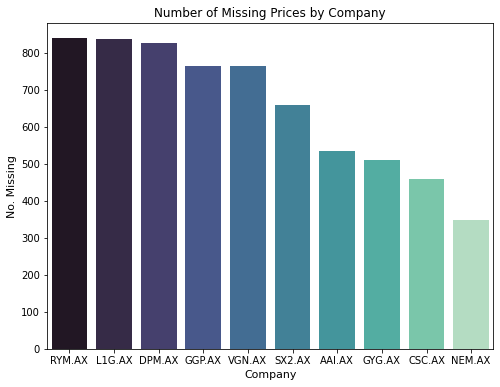

In [58]:
ticker_missing_df = prices_df.isna().sum()

ticker_missing_df = ticker_missing_df.loc[ticker_missing_df > 0].sort_values(ascending=False).reset_index().rename(columns={
    "index": "Company", 
    0: "No. Missing"
})

missing_companies = list(ticker_missing_df["Company"])

print(f"There are {ticker_missing_df.shape[0]} missing companies: {missing_companies}")

plt.figure(figsize=(8, 6))
sns.barplot(data=ticker_missing_df[:10], x="Company", y="No. Missing", palette="mako")
plt.title("Number of Missing Prices by Company", fontsize=12)
plt.xlabel("Company", fontsize=11)
plt.ylabel("No. Missing", fontsize=11)
plt.show()

In [62]:
listing_summary = []    
for company in missing_companies:
    s = prices_df[["Date", company]].dropna()
    listing_summary.append({
        "Company": company, 
        "Start Date": s["Date"].min(),
        "End Date": s["Date"].max()
    })
listing_df = pd.DataFrame(listing_summary)
listing_df

,Company,Start Date,End Date
0,RYM.AX,2025-10-06,2026-06-12
1,L1G.AX,2025-10-03,2026-06-12
2,DPM.AX,2025-09-18,2026-06-12
3,GGP.AX,2025-06-24,2026-06-12
4,VGN.AX,2025-06-24,2026-06-12
5,SX2.AX,2025-01-17,2026-06-12
6,AAI.AX,2024-07-24,2026-06-12
7,GYG.AX,2024-06-20,2026-06-12
8,CSC.AX,2024-04-08,2026-06-12
9,NEM.AX,2023-10-27,2026-06-12


We 

RYM.AX    839
L1G.AX    838
DPM.AX    827
VGN.AX    765
GGP.AX    765
SX2.AX    658
AAI.AX    534
GYG.AX    510
CSC.AX    459
NEM.AX    349
FRW.AX    336
ASK.AX    286
LNW.AX    240
IFL.AX     31
NSR.AX     22
PME.AX      0
PRU.AX      0
PMV.AX      0
PNI.AX      0
PLS.AX      0
PPT.AX      0
PRN.AX      0
Date        0
PXA.AX      0
QAN.AX      0
QUB.AX      0
REA.AX      0
REG.AX      0
REH.AX      0
RGN.AX      0
dtype: int64

## Missingness Treatment